In [136]:
# 1) importando libs
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib import pyplot as plt

In [117]:
# 2) criando dataframe com base no .csv
df = pd.read_csv("/content/dados_nao_tratados_imoveis.csv")
df

,tamanho_m2,n_quartos,bairro,idade_imovel,preco
0,94.9,3,Zona Sul,54.0,581545.47
1,NaN,3,Zona Norte,10.0,438154.41
2,99.4,3,z. norte,27.0,660864.60
3,125.7,4,Zona Norte,45.0,716068.37
4,73.0,2,Zona Norte,31.0,381780.77
...,...,...,...,...,...
1995,112.1,4,Subúrbio,48.0,490181.92
1996,79.2,3,Zona Norte,18.0,505325.69
1997,53.5,2,Zona Sul,37.0,297697.67
1998,75.1,3,Zona Sul,35.0,501870.76


In [118]:
# 3) observando a tabela, vemos que existem muitos valores nulos, nomes diferentes na coluna bairro (ex. z. norte e Zona Norte)
df.isnull().sum()

,0
tamanho_m2,100
n_quartos,0
bairro,0
idade_imovel,49
preco,0


In [119]:
# 4) removendo valores duplicados, se houver
df.drop_duplicates()

,tamanho_m2,n_quartos,bairro,idade_imovel,preco
0,94.9,3,Zona Sul,54.0,581545.47
1,NaN,3,Zona Norte,10.0,438154.41
2,99.4,3,z. norte,27.0,660864.60
3,125.7,4,Zona Norte,45.0,716068.37
4,73.0,2,Zona Norte,31.0,381780.77
...,...,...,...,...,...
1995,112.1,4,Subúrbio,48.0,490181.92
1996,79.2,3,Zona Norte,18.0,505325.69
1997,53.5,2,Zona Sul,37.0,297697.67
1998,75.1,3,Zona Sul,35.0,501870.76


In [120]:
# 5) fazendo a mediana de tamanho do metro quadrado para colocar nos valores zero.
mediana_m2 = df['tamanho_m2'].median()
df['tamanho_m2'] = df['tamanho_m2'].fillna(mediana_m2)

df.isnull().sum()

,0
tamanho_m2,0
n_quartos,0
bairro,0
idade_imovel,49
preco,0


In [121]:
df['tamanho_m2'].value_counts()

,count
tamanho_m2,
81.1,102
20.0,35
86.7,8
57.4,7
64.1,7
...,...
39.9,1
109.2,1
93.0,1


In [122]:
# 6) com os valores nulos propriamente preenchidos, vamos corrigir a coluna bairro - primeiro olhamos os valores na coluna inteira
df['bairro'].value_counts()

,count
bairro,
Centro,478
Zona Norte,470
Subúrbio,469
Zona Sul,464
centro,49
ZONA SUL,40
z. norte,30


In [123]:
# 7) vemos que existem 2 tipos de centro, zona norte e zona sul.

# remove espaços em branco no início e no fim da palavra
df['bairro'] = df['bairro'].str.strip()
# padronizando para a primeira letra maiúscula
df['bairro'] = df['bairro'].str.title()
# substituindo manualmente o "z.norte"
df['bairro'] = df['bairro'].replace({'Z. Norte': 'Zona Norte'})

df['bairro'].value_counts()

,count
bairro,
Centro,527
Zona Sul,504
Zona Norte,500
Subúrbio,469


In [124]:
# 8) vendo se a coluna "n_quartos" tem algo a ser tratado
df['n_quartos'].value_counts()

,count
n_quartos,
3,727
2,600
4,329
1,209
5,72
três,28
dois,20
-1,15


In [125]:
# 9) trocando o valor negativo por positivo, assumindo que foi um erro de digitação
df['n_quartos'] = df['n_quartos'].replace({'-1': 1})

# 10) trocando as palavras por números
df['n_quartos'] = df['n_quartos'].replace({'dois': 2, 'três': 3})

# 11) tranformando a coluna para dados numéricos apenas
df['n_quartos'] = pd.to_numeric(df['n_quartos'])

df['n_quartos'].value_counts()

,count
n_quartos,
3,755
2,620
4,329
1,224
5,72


In [126]:
# 12) vendo se a coluna "idade_imovel" tem algo a ser tratado além dos valores nulosm - que outlier absurdo!!!
df['idade_imovel'].value_counts()

,count
idade_imovel,
44.0,47
53.0,45
46.0,44
54.0,42
12.0,41
...,...
28.0,24
35.0,23
32.0,22


In [127]:
# 13) trocando os valores absurdos por nulo
df['idade_imovel'] = df['idade_imovel'].replace({999: np.nan})

# 14) diferente da idade, fazendo a mediana que é à prova de outliers
mediana_idade = df['idade_imovel'].median()
df['idade_imovel'] = df['idade_imovel'].fillna(mediana_idade)
df['idade_imovel'].value_counts()

,count
idade_imovel,
30.0,94
44.0,47
53.0,45
46.0,44
54.0,42
12.0,41
22.0,40
34.0,40
15.0,40


In [128]:
# 15) transformando a coluna bairro em numérico, preparando para a criação do modelo
df = pd.get_dummies(df, columns=['bairro'], drop_first=True)

In [129]:
# 16) separando as variáveis
x = df.drop('preco', axis=1)
y = df['preco']

In [130]:
# 17) dividir os dados em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

In [131]:
# 18) criando o modelo - nesse caso não é necessário escalonamento
modelo_rf = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=10)
modelo_rf.fit(x_treino, y_treino)

modelo_lr = LinearRegression()
modelo_lr.fit(x_treino, y_treino)

LinearRegression()

In [132]:
# 18) fazendo o r squared (acurácia da regressão) e média de erro
previsoes_rf = modelo_rf.predict(x_teste)
r2_rf = r2_score(y_teste, previsoes_rf)
mae_rf = mean_absolute_error(y_teste, previsoes_rf)

previsoes_lr = modelo_lr.predict(x_teste)
r2_lr = r2_score(y_teste, previsoes_lr)
mae_lr = mean_absolute_error(y_teste, previsoes_lr)

In [133]:
# 19) printando
print(f"R² (RF): {r2_rf * 100:.2f}%")
print(f"MAE: R$ {mae_rf:.2f}")

print(f"R² (RF): {r2_lr * 100:.2f}%")
print(f"MAE: R$ {mae_lr:.2f}")

R² (RF): 93.18%
MAE: R$ 33617.64
R² (RF): 89.51%
MAE: R$ 40666.18


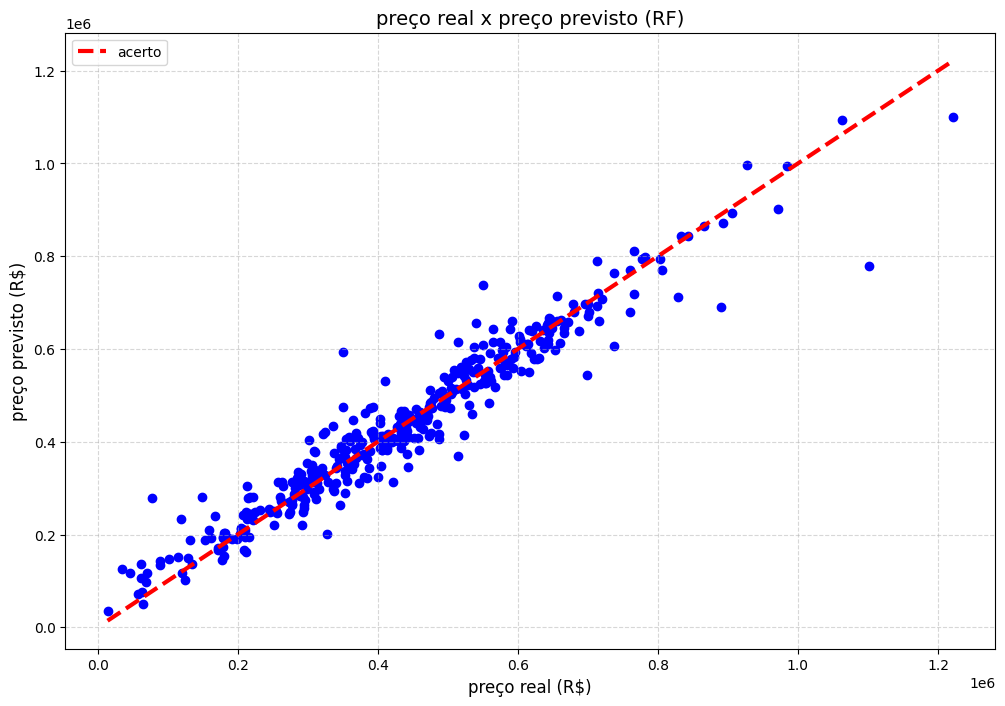

In [134]:
# 20) definindo tamanho do gráfico
plt.figure(figsize=(12, 8))

# 21) criando o gráfico de dispersão e linha de acerto na mosca
plt.scatter(y_teste, previsoes_rf, color='blue')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=3, label='acerto')

# 22) criando labels e linha de grade
plt.title('preço real x preço previsto (RF)', fontsize=14)
plt.xlabel('preço real (R$)', fontsize=12)
plt.ylabel('preço previsto (R$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

In [135]:
# 23) salvar modelo
with open("modelo_rf.pkl", "wb") as f:
    pickle.dump(modelo_rf, f)
with open("modelo_lr.pkl", "wb") as f:
    pickle.dump(modelo_lr, f)

print("salvou modelos")

salvou modelos
